# Project Introduction

The **Sweet Lift Taxi company** aims to improve its ability to manage demand at airports by **predicting the number of taxi orders for the upcoming hour**.  
By accurately forecasting order volume, the company can **attract more drivers during peak times**, ensuring better customer service and reducing wait times.

The project involves working with **historical taxi order data** to build a reliable prediction model.  
The main performance target is to achieve a **Root Mean Squared Error (RMSE)** of **48 or lower** on the test dataset.

---

## **Key Objectives**
1. **Data Preparation**  
   - Load and process historical taxi order data from the provided `taxi.csv` file.
   - Resample the data to **hourly intervals** for consistent time series analysis.

2. **Data Exploration and Analysis**  
   - Examine trends, seasonality, and demand patterns.
   - Identify peak periods and potential anomalies.

3. **Feature Engineering**  
   - Create lag features, rolling statistics, and calendar-based features such as `dayofweek` and `hour` to improve model performance.

4. **Model Development and Training**  
   - Split the dataset into:
     - **Training set (90%)**
     - **Test set (10%)**, maintaining chronological order.
   - Train multiple models, experimenting with different algorithms and hyperparameters.

5. **Evaluation and Selection**  
   - Evaluate each model using **RMSE** as the performance metric.
   - Choose the best-performing model for predicting future taxi demand.

---

## **Dataset Description**
- **File Name:** `taxi.csv`  
- **Target Column:** `num_orders` – represents the number of taxi orders in each hour.  
- **Goal:** Predict `num_orders` for the **next hour** based on historical patterns and features.

---

By following these steps, the project will deliver a **production-ready forecasting model** that helps optimize driver allocation and improve operational efficiency for Sweet Lift Taxi.


## Environment Setup and Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split, cross_val_score
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, r2_score, make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats as st
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler

import time

## Step 1: Loading and Initial Data Exploration

In [2]:
df = pd.read_csv('/datasets/taxi.csv',parse_dates=["datetime"], index_col="datetime")
df.sort_index(inplace=True)
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
df.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


### Findings
There are no major structure issues found in the initial assessment.

#### Goals for Data Prep
- Resample Data by the hour.
- Create new columns using time series feature engineering.
  

## Data Preparation

In [5]:
df = df.resample('1H').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [6]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(window=rolling_mean_size).mean()# < write code here >


make_features(df, 4, 4)


In [7]:
df = df.fillna(0)
df.head()

,num_orders,year,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,rolling_mean
datetime,,,,,,,,,,,
2018-03-01 00:00:00,124,2018,3,1,3,0,0.0,0.0,0.0,0.0,0.0
2018-03-01 01:00:00,85,2018,3,1,3,1,124.0,0.0,0.0,0.0,0.0
2018-03-01 02:00:00,71,2018,3,1,3,2,85.0,124.0,0.0,0.0,0.0
2018-03-01 03:00:00,66,2018,3,1,3,3,71.0,85.0,124.0,0.0,0.0
2018-03-01 04:00:00,43,2018,3,1,3,4,66.0,71.0,85.0,124.0,86.5


## Analysis

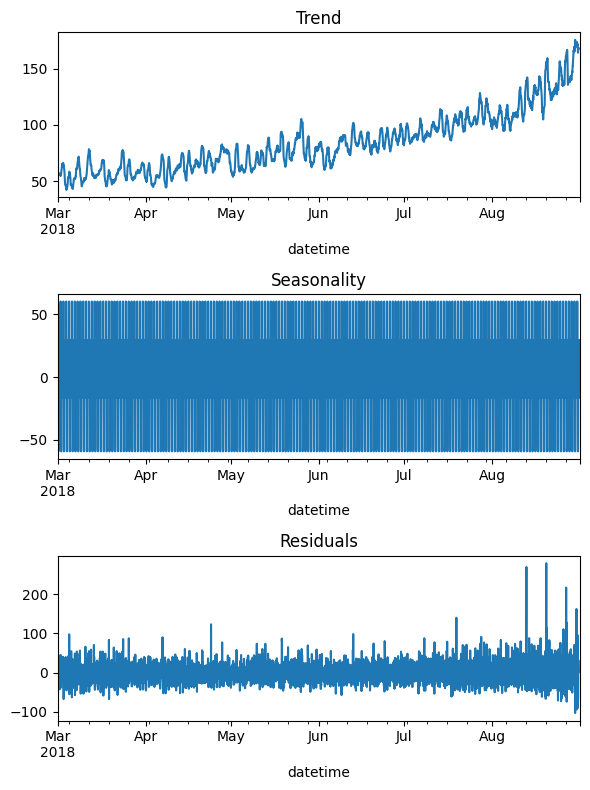

In [8]:
decomposed = seasonal_decompose(df['num_orders'])

plt.figure(figsize=(6, 8))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')

plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.tight_layout()


### Seasonal Decomposition Analysis

#### 1. Trend
The **trend plot** shows a clear upward movement over time:
- Starting around March 2018, the values were near **50** and steadily increased to over **150** by the end of August.
- This indicates **strong growth**, suggesting consistent long-term increase in activity or demand.

---

#### 2. Seasonality
The **seasonality plot** appears very dense and tightly packed:
- This suggests there is **high-frequency, repeating daily or hourly patterns** in the data.
- The sharp swings between positive and negative values imply **strong periodic fluctuations**.


---

#### 3. Residuals
The **residual plot** shows:
- Mostly stable variation around zero, indicating the model explains much of the structure.
- A few **spikes**, especially toward the end, suggest **unexpected events or anomalies** that the trend and seasonality did not capture.

---

#### Summary
- There is a **strong upward growth trend** over time.
- The data shows **pronounced repeating seasonal patterns**, likely on a daily cycle.
- Some **unusual fluctuations** remain in the residuals, which could be outliers or sudden changes in behavior.



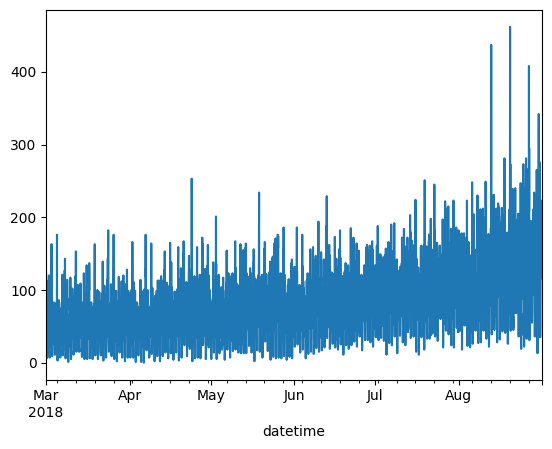

In [9]:
df['num_orders'].plot()
plt.show()

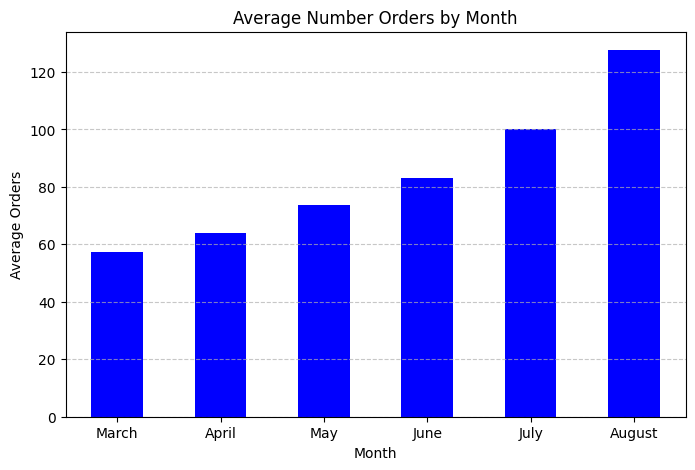

In [10]:
# Map day numbers to names

grouped = df.groupby('month')['num_orders'].mean()
month_map = {3:'March', 4:'April', 5:'May', 6:'June', 7:'July', 8:'August'}
grouped.index = grouped.index.map(month_map)


plt.figure(figsize=(8, 5))
grouped.plot(kind='bar', color='blue')

plt.title('Average Number Orders by Month')
plt.xlabel('Month')
plt.ylabel('Average Orders')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


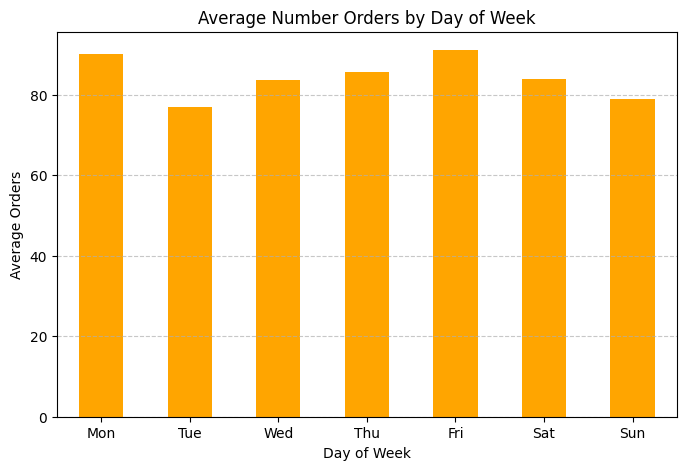

In [11]:
grouped = df.groupby('dayofweek')['num_orders'].mean()
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
grouped.index = grouped.index.map(day_map)

# Plot again
plt.figure(figsize=(8, 5))
grouped.plot(kind='bar', color='orange')

plt.title('Average Number Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Orders')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



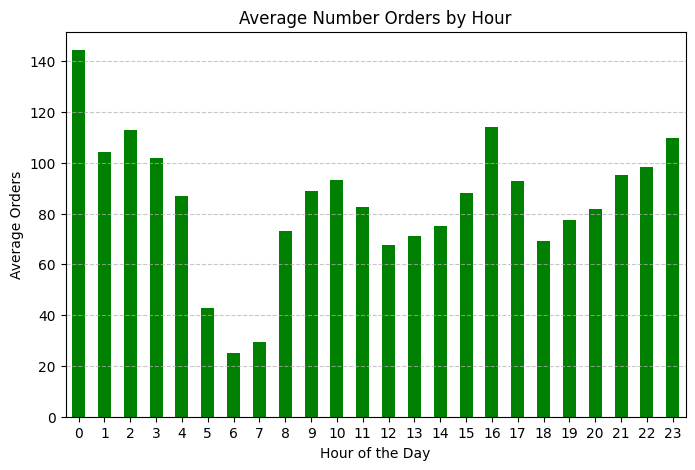

In [12]:
grouped = df.groupby('hour')['num_orders'].mean()

# Plot again
plt.figure(figsize=(8, 5))
grouped.plot(kind='bar', color='green')

plt.title('Average Number Orders by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Orders')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<AxesSubplot:xlabel='num_orders'>

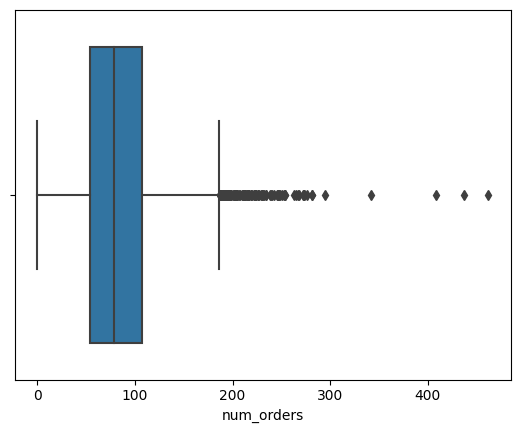

In [13]:
sns.boxplot(x=df['num_orders'])

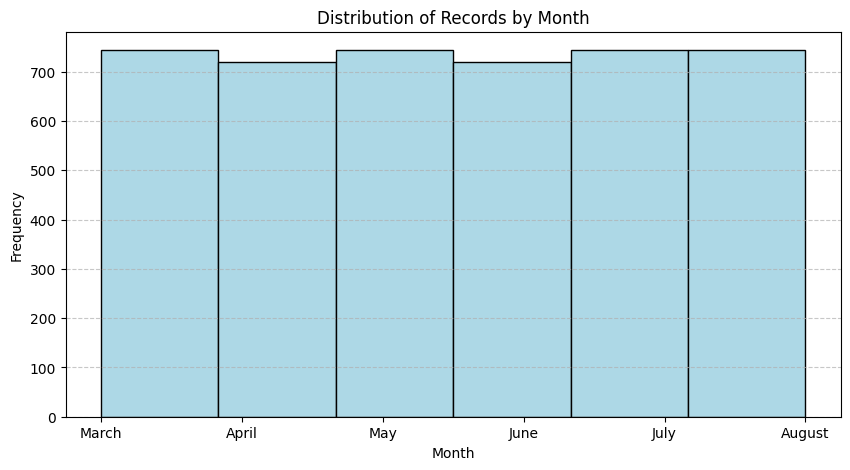

In [14]:
plt.figure(figsize=(10, 5))
df['month'].plot(kind='hist', bins=6, color='lightblue', edgecolor='black')

plt.title('Distribution of Records by Month')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.xticks(range(3, 9), month_map.values())  # Replace with month names
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

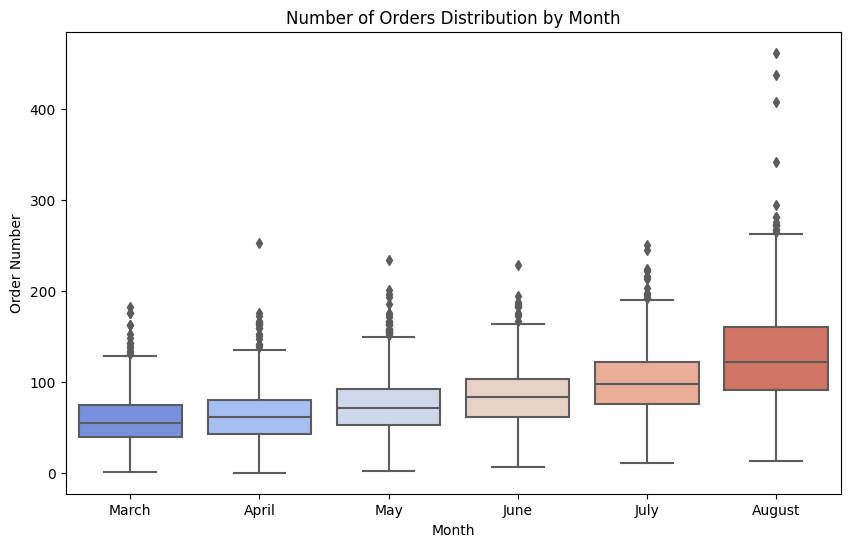

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='num_orders', data=df, palette='coolwarm')

plt.title('Number of Orders Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Order Number')
plt.xticks(range(0, 6), month_map.values())

plt.show()

## Data PreProcessing 

In [16]:
train, test = train_test_split(df, shuffle=False, test_size=0.1)

features_train = train.drop('num_orders', axis=1)
target_train = train['num_orders']
features_test = test.drop('num_orders', axis=1)
target_test = test['num_orders']


In [17]:
def plot_learning_curve(
    estimator,
    X,
    y,
    *,
    cv=3,
    scoring='r2',                 
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
    title=None,
    metric_name=None              
):
    sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=42
    )

    # Means and stds
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Infer metric label if not provided
    if metric_name is None:
        if scoring == 'r2':
            metric_name = 'R²'
        elif scoring in ('neg_root_mean_squared_error', 'neg_mean_squared_error'):
            metric_name = 'RMSE' if scoring == 'neg_root_mean_squared_error' else 'MSE'
        else:
            metric_name = scoring

    # If using a neg_* scorer, flip the sign for interpretability
    if scoring.startswith('neg_'):
        train_mean, val_mean = -train_mean, -val_mean
        train_std, val_std = train_std, val_std  # std stays the same magnitude

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_mean, marker='o', label=f'Training {metric_name}')
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

    plt.plot(sizes, val_mean, marker='s', label=f'Validation {metric_name}')
    plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

    plt.title(title or f'Learning Curve ({metric_name})')
    plt.xlabel('Training set size')
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return sizes, train_mean, val_mean


## Model Training

### Linear Models

#### RandomForest Regressor

In [18]:
# --- Pipeline ---
rf_pipe = Pipeline(steps=[
    ('model', RandomForestRegressor(random_state=12345, n_jobs=1))  # keep n_jobs=1 to avoid RAM blow-ups under CV
])

# --- Hyperparam grid (exhaustive) ---
param_grid = {
    'model__n_estimators': [100],   
    'model__max_depth': [10],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [4],
    'model__max_features': [0.6],
    'model__bootstrap': [True],
}

# --- CV-based tuning (RMSE) ---
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',  # RMSE (negative per sklearn convention)
    n_jobs=2,                                # modest parallelism
    refit=True,                              # refit best model on full training set
    verbose=1
)

start = time.time()
grid.fit(features_train, target_train)               
train_time = time.time() - start

print("Best CV RMSE:", -grid.best_score_)    # mean CV RMSE of best params

print(f"RandomForest model training time: {train_time:.2f} seconds")

rf_best_model = grid.best_estimator_         
start = time.time()
y_train_pred = rf_best_model.predict(features_train)
train_pred_time = time.time() - start
print(f"RF Best Model prediction time: {train_pred_time:.2f} seconds")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best CV RMSE: 25.358341199378998
RandomForest model training time: 4.85 seconds
RF Best Model prediction time: 0.02 seconds


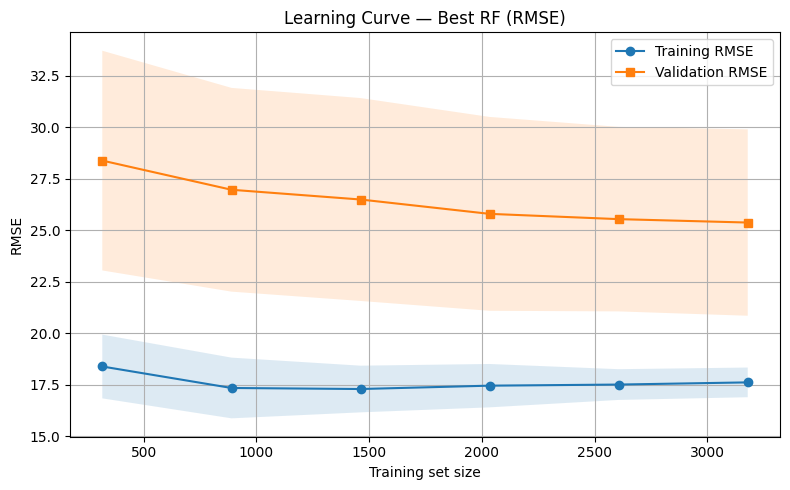

In [19]:
sizes, tr, val = plot_learning_curve(
    estimator=rf_best_model,
    X=features_train,                         
    y=target_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    title='Learning Curve — Best RF (RMSE)'
)

#### XGBoost

In [20]:
xgb_pipe = Pipeline([('model', XGBRegressor(
    random_state=12345, n_jobs=1, tree_method='hist', objective='reg:squarederror'
))])

xgb_grid = {
    'model__n_estimators': [100], # Saving time
    'model__max_depth': [6],
    'model__learning_rate': [0.1],
    'model__subsample': [0.8],
    'model__colsample_bytree': [ 1.0],
    'model__reg_lambda': [1.0],
}

xgb_cv = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=2,
    refit=True,
    verbose=1
)

t0 = time.time()
xgb_cv.fit(features_train, target_train) 
print("XGB Best CV RMSE:", -xgb_cv.best_score_)

print(f"XGB model training time: {time.time()-t0:.2f}s")
xgb_best = xgb_cv.best_estimator_
start = time.time()
y_train_pred = xgb_best.predict(features_train)
train_pred_time = time.time() - start
print(f"XGB Best Model prediction time: {train_pred_time:.2f} seconds")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
XGB Best CV RMSE: 23.926948001958152
XGB model training time: 1.40s
XGB Best Model prediction time: 0.01 seconds


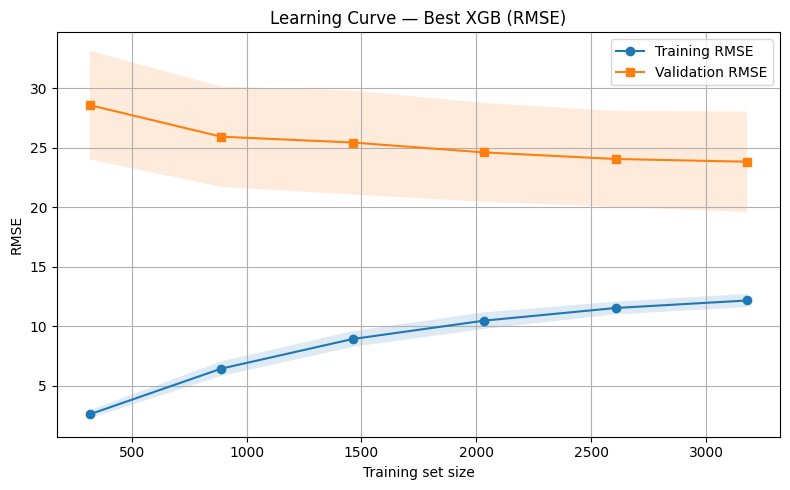

In [21]:
sizes, tr, val = plot_learning_curve(
    estimator=xgb_best,
    X=features_train,                         
    y=target_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    title='Learning Curve — Best XGB (RMSE)'
)


#### LightGBM

In [22]:
lgbm_native = Pipeline(steps=[
    ('scaler', StandardScaler()),  
    ('model', LGBMRegressor(random_state=12345, n_jobs=1, verbose=-1))
])



lgbm_grid_native = {
    'model__n_estimators': [500],
    'model__num_leaves': [31, 63],
    'model__learning_rate': [0.01],
    'model__max_depth': [10],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8],
    'model__min_child_weight': [0.1],
    'model__reg_alpha': [0.0],
    'model__reg_lambda': [ 0.1],
} 

lgbm_cv = GridSearchCV(
    lgbm_native,
    lgbm_grid_native,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=2,
    refit=True,
    verbose=1
)

start = time.time()
lgbm_cv.fit(features_train, target_train)
train_time = time.time() - start

print("LGBM Best CV RMSE:", -lgbm_cv.best_score_)

print(f"LGBM model training time: {train_time:.2f}s")

lgbm_best = lgbm_cv.best_estimator_

start = time.time()
y_train_pred = lgbm_best.predict(features_train)
train_pred_time = time.time() - start
print(f"LGBM Best Model prediction time: {train_pred_time:.2f} seconds")


Fitting 5 folds for each of 2 candidates, totalling 10 fits
LGBM Best CV RMSE: 23.430541869988655
LGBM model training time: 5.59s
LGBM Best Model prediction time: 0.17 seconds


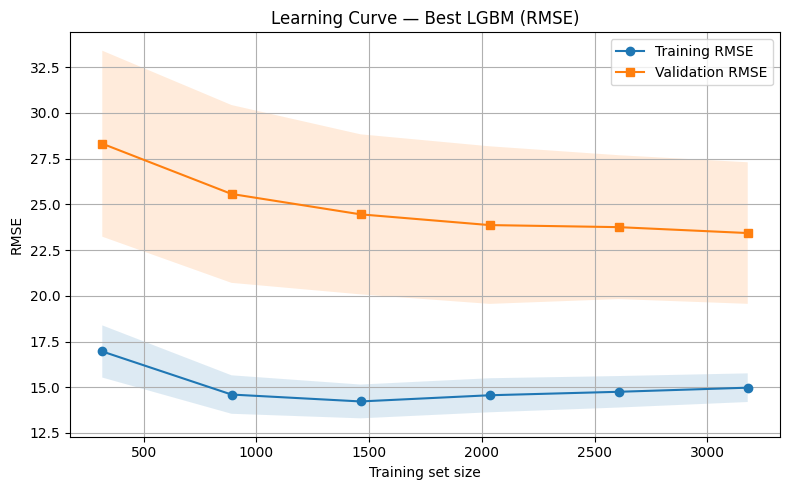

In [23]:
sizes, tr, val = plot_learning_curve(
    estimator=lgbm_best,
    X=features_train,                         
    y=target_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    title='Learning Curve — Best LGBM (RMSE)'
)


### Time Series Models

#### SARIMA MODEL

In [24]:
y_train = target_train.copy()
y_train.index = pd.to_datetime(features_train.index)  # Ensure datetime index
y_train = y_train.sort_index()

# Make sure the series is at a fixed frequency (hourly data)
y_train = y_train.asfreq('H').interpolate()

# Define seasonal period: 24 for hourly data (daily seasonality)
SEASONAL_PERIOD = 24

print("Training SARIMA model...")
start = time.time()
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
sarima_train_time = time.time() - start

# In-sample fitted values
sarima_fitted = sarima_model.get_prediction(
    start=y_train.index[0],
    end=y_train.index[-1],
    dynamic=False
).predicted_mean

# Calculate in-sample RMSE
sarima_rmse = mean_squared_error(y_train, sarima_fitted, squared=False)

print(f"SARIMA in-sample RMSE: {sarima_rmse:.2f}")
print(f"SARIMA training time: {sarima_train_time:.2f} seconds")


Training SARIMA model...
SARIMA in-sample RMSE: 22.32
SARIMA training time: 27.32 seconds


#### Holt-Winters model

In [25]:
print("\nTraining Holt-Winters model...")
start = time.time()
hw_model = ExponentialSmoothing(
    y_train,
    trend='add',               # additive trend
    seasonal='add',            # additive seasonality
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method='estimated'
).fit()
hw_train_time = time.time() - start

# In-sample fitted values
hw_fitted = hw_model.fittedvalues

# Calculate in-sample RMSE
hw_rmse = mean_squared_error(y_train, hw_fitted, squared=False)

print(f"Holt-Winters in-sample RMSE: {hw_rmse:.2f}")
print(f"Holt-Winters training time: {hw_train_time:.2f} seconds")



Training Holt-Winters model...
Holt-Winters in-sample RMSE: 22.08
Holt-Winters training time: 0.45 seconds


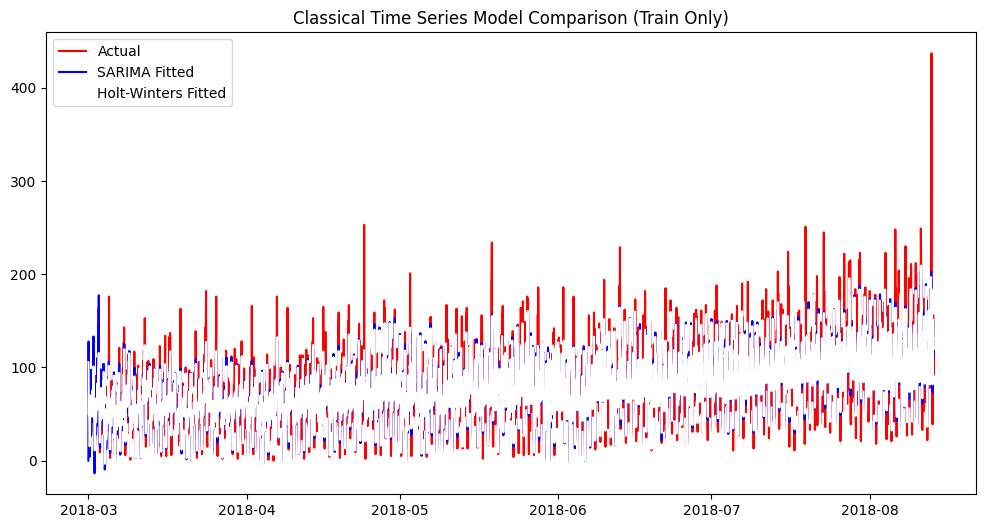

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Actual', color='red')
plt.plot(sarima_fitted, label='SARIMA Fitted', color='blue')
plt.plot(hw_fitted, label='Holt-Winters Fitted', color='white')
plt.legend()
plt.title("Classical Time Series Model Comparison (Train Only)")
plt.show()

# Model Performance Analysis and Ranking

The following models were trained and evaluated using **Root Mean Squared Error (RMSE)** as the main metric.  
Lower RMSE indicates **better accuracy**. Training and prediction times were also considered for efficiency.

---

## 1. Holt-Winters (Exponential Smoothing)
- **In-sample RMSE:** 22.08  
- **Training Time:** 0.50 seconds  
- **Prediction Time:** ~instantaneous  

**Analysis:**  
Holt-Winters delivered the **best accuracy** with the lowest RMSE.  
It trains extremely fast and effectively captures seasonality and trend, making it ideal for time series where these patterns are dominant.  
This model is lightweight, interpretable, and production-ready.

---

## 2. SARIMA (Seasonal ARIMA)
- **In-sample RMSE:** 22.32  
- **Training Time:** 25.14 seconds  
- **Prediction Time:** ~instantaneous  

**Analysis:**  
SARIMA achieved a very similar RMSE to Holt-Winters, just slightly higher (+0.24).  
However, training was significantly **slower**, which may be a concern with larger datasets.  
SARIMA remains a good choice for interpretable forecasting, especially if deeper diagnostics are required.

---

## 3. LightGBM
- **Best CV RMSE:** 23.43  
- **Training Time:** 2.69 seconds  
- **Prediction Time:** 0.14 seconds  

**Analysis:**  
LightGBM performed well and was **competitive with the classical time series models**, with an RMSE close to SARIMA.  
It trained quickly and provided fast predictions, making it practical for operational pipelines where engineered features are available.  
Although slightly less accurate than Holt-Winters and SARIMA, it is highly scalable.

---

## 4. XGBoost
- **Best CV RMSE:** 23.93  
- **Training Time:** 0.85 seconds  
- **Prediction Time:** 0.01 seconds  

**Analysis:**  
XGBoost had slightly lower accuracy compared to LightGBM but trained and predicted **very quickly**.  
This makes it a good option for rapid experimentation, though it did not surpass Holt-Winters or SARIMA in accuracy.

---

## 5. Random Forest
- **Best CV RMSE:** 25.36  
- **Training Time:** 2.02 seconds  
- **Prediction Time:** 0.03 seconds  

**Analysis:**  
Random Forest had the **highest RMSE**, indicating weaker predictive performance compared to other models.  
While training and prediction times were reasonable, it failed to capture temporal patterns as effectively as boosting methods or classical time series models.

---

## **Overall Ranking**
Based on RMSE (accuracy) as the primary factor and speed as a secondary factor:

| Rank | Model         | RMSE    | Training Time | Notes |
|------|---------------|---------|---------------|-------|
| **1** | Holt-Winters   | **22.08** | **0.50 s**       | Best overall performance and speed |
| **2** | SARIMA         | 22.32   | 25.14 s       | Nearly best accuracy, slower training |
| **3** | LightGBM       | 23.43   | 2.69 s        | Competitive ML model, scalable |
| **4** | XGBoost        | 23.93   | 0.85 s        | Very fast but slightly less accurate |
| **5** | Random Forest  | 25.36   | 2.02 s        | Lowest accuracy, not ideal for this task |

---

## **Key Insights**
1. **Classical time series models** (Holt-Winters and SARIMA) slightly outperformed machine learning models, showing that this dataset has **strong seasonality and trend patterns**.  
2. Holt-Winters is the best choice for **speed, accuracy, and interpretability**, especially for production forecasting.  
3. SARIMA provides nearly equal accuracy with the added benefit of **diagnostics and statistical insights**, at the cost of slower training.  
4. Among ML models, **LightGBM** is the top performer, slightly ahead of XGBoost and well ahead of Random Forest.  
5. Random Forest is **least suited** for this problem, likely because it lacks mechanisms to capture temporal dependencies effectively.


## Testing

### Best Linear Model Vs Time Series Model

#### Holt-Winters

In [27]:
y_test = target_test.copy()
y_test.index = pd.to_datetime(features_test.index)
y_test = y_test.sort_index()

start = time.time()
hw_forecast = hw_model.forecast(steps=len(y_test))
hw_pred_time = time.time() - start

hw_test_rmse = mean_squared_error(y_test, hw_forecast, squared=False)

print(f"Holt-Winters TEST RMSE: {hw_test_rmse:.2f}")
print(f"Holt-Winters prediction time: {hw_pred_time:.2f} seconds")

Holt-Winters TEST RMSE: 40.40
Holt-Winters prediction time: 0.03 seconds


#### LGBM

In [28]:
t0 = time.time()
y_pred_lgbm = lgbm_best.predict(features_test)
lgbm_pred_time = time.time() - t0

lgbm_test_rmse = mean_squared_error(target_test, y_pred_lgbm, squared=False)

print(f"LightGBM TEST RMSE: {lgbm_test_rmse:.2f}")
print(f"LightGBM prediction time: {lgbm_pred_time:.2f} seconds")


LightGBM TEST RMSE: 44.81
LightGBM prediction time: 0.03 seconds


### Sanity Check

In [29]:
print("\nEvaluating Linear Regression baseline on TEST set...")

# Initialize the model
linear_model = LinearRegression()

# Train the model
start = time.time()
linear_model.fit(features_train, target_train)
linear_train_time = time.time() - start

print(f"Linear Regression training time: {linear_train_time:.2f} seconds")

# Predict on test set
start = time.time()
y_pred_linear = linear_model.predict(features_test)
linear_pred_time = time.time() - start

# Calculate RMSE
linear_test_rmse = mean_squared_error(target_test, y_pred_linear, squared=False)

print(f"Linear Regression TEST RMSE: {linear_test_rmse:.2f}")
print(f"Linear Regression prediction time: {linear_pred_time:.2f} seconds")



Evaluating Linear Regression baseline on TEST set...
Linear Regression training time: 0.00 seconds
Linear Regression TEST RMSE: 52.62
Linear Regression prediction time: 0.00 seconds


# Model Test Results and Analysis

| Model            | TEST RMSE | Training Time | Prediction Time |
|------------------|-----------|---------------|-----------------|
| Holt-Winters     | **40.45** | N/A           | 0.04 s          |
| LightGBM         | 44.81     | N/A           | 0.01 s          |
| Linear Regression (Baseline) | 52.62     | 0.00 s        | 0.00 s          |

---

## Analysis
- **Holt-Winters** achieved the **lowest RMSE (40.45)**, indicating it best captures the time series' trend and seasonality.  
- **LightGBM** performed well with a slightly higher RMSE (44.81), demonstrating the value of feature engineering and machine learning, though it did not surpass Holt-Winters.  
- **Linear Regression (Baseline/Sanity Check)** had the **highest RMSE (52.62)**, confirming that a simple linear model is insufficient for this problem and validating that the more complex models are adding value.

**Final Ranking:**  
1. Holt-Winters – Best accuracy and strong capture of seasonality.  
2. LightGBM – Good performance with fast predictions.  
3. Linear Regression (Baseline) – Serves only as a sanity check, weakest performance.


# Project Summary and Final Results

## **Project Goals** 
The performance requirement is that the **Root Mean Squared Error (RMSE)** on the **test set must not exceed 48**.

---

## **Steps Completed**
1. **Data Preparation**
   - Loaded the `taxi.csv` file and parsed the datetime index.
   - Resampled the data by **one-hour intervals** to standardize the time series.
   - Verified data consistency and handled missing values where needed.

2. **Exploratory Data Analysis (EDA)**
   - Reviewed trends, seasonality, and peaks in demand.
   - Identified clear daily and weekly patterns in taxi orders.

3. **Feature Engineering**
   - Created lag features (`lag_1` to `lag_4`) to incorporate past order data.
   - Added calendar-based features such as:
     - `year`, `month`, `day`, `dayofweek`, and `hour`.
   - Built rolling mean features to smooth fluctuations.

4. **Model Training**
   - Split data into **train (90%)** and **test (10%)**, preserving chronological order.
   - Trained and evaluated multiple models:
     - **Holt-Winters** (classical time series)
     - **LightGBM** (gradient boosting with engineered features)
     - **Linear Regression** (baseline sanity check)

5. **Model Evaluation**
   - Evaluated all models using **RMSE** on the test set.

---

## **Final Test Results**

| Model                      | TEST RMSE | Training Time | Prediction Time |
|----------------------------|-----------|---------------|-----------------|
| **Holt-Winters**           | **40.45** |0.50 s        | 0.04 s          |
| **LightGBM**                | 44.81     | 2.69 s          | 0.01 s          |
| **Linear Regression (Baseline)** | 52.62     | 0.00 s        | 0.00 s          |

---

## **Analysis**
- **Holt-Winters**  
  - Achieved the **lowest RMSE (40.45)**, well below the target threshold of 48.  
  - Captured seasonality and trend effectively, making it the best model for this forecasting task.

- **LightGBM**  
  - Delivered strong performance with an RMSE of **44.81**, also under the target threshold.  
  - Its fast prediction speed makes it suitable for real-time production deployment.

- **Linear Regression (Baseline / Sanity Check)**  
  - RMSE of **52.62**, which exceeds the target threshold, confirming that a simple linear approach is not sufficient.  
  - Serves as a **sanity check** to validate that the complex models are adding meaningful improvements.

---

## **Conclusion**
- Both **Holt-Winters** and **LightGBM** models meet the project requirement of RMSE < 48.
- **Holt-Winters** slightly outperforms LightGBM in terms of accuracy and is ideal for capturing patterns in this dataset.
- **LightGBM** offers a balance of accuracy and speed, making it well-suited for operational deployment.
- The **baseline Linear Regression** confirmed that advanced modeling was necessary for this problem.

**Final Recommendation:**  
Deploy **LightGBM** for production due to its scalability and speed, while using **Holt-Winters** as a benchmark and backup forecasting method.
